(ch:ml-project)=
 # 머신러닝 프로젝트
 
 머신러닝 프로젝트는 데이터를 이용하여 예측 모델을 만들고, 그 모델이 새로운 데이터에 대해서도 쓸 만한지 확인하는 과정이다. 여기서는 파머 펭귄 데이터셋을 이용하여 머신러닝 프로젝트의 기본 흐름을 간단히 살펴본다.
 
 이 장에서는 두 가지 문제를 다룬다.
 
 - **분류**: 펭귄의 신체 측정값을 이용하여 종을 예측한다.
 - **회귀**: 펭귄의 신체 측정값을 이용하여 몸무게를 예측한다.
 
 <div align="center">
   <img src="images/palmer-penguins.jpg" width="650">
 </div>

## 프로젝트 흐름
 
 머신러닝 프로젝트는 보통 다음 순서로 진행된다.
 
 1. 문제를 정의한다.
 2. 데이터를 불러오고 구조를 확인한다.
 3. 탐색적 데이터 분석으로 데이터의 특징을 파악한다.
 4. 훈련 세트와 테스트 세트로 나눈다.
 5. 머신러닝 모델을 훈련한다.
 6. 테스트 세트로 모델을 평가한다.
 7. 결과를 해석하고 개선 방향을 정한다.
 
 실제 프로젝트에서는 전처리, 특성 공학, 모델 선택, 하이퍼파라미터 튜닝이 훨씬 복잡해질 수 있다. 하지만 기본 뼈대는 위 흐름에서 크게 벗어나지 않는다.

## 데이터셋
 
 파머 펭귄 데이터셋은 남극 팔머 군도에서 관찰된 세 종류의 펭귄에 대한 자료이다. 세 종은 다음과 같다.
 
 - Adelie
 - Chinstrap
 - Gentoo
 
 주요 특성은 다음과 같다.
 
 | 특성 | 설명 |
 | :--- | :--- |
 | `species` | 펭귄 종 |
 | `island` | 관찰된 섬 |
 | `bill_length_mm` | 부리 길이(mm) |
 | `bill_depth_mm` | 부리 깊이(mm) |
 | `flipper_length_mm` | 날개 길이(mm) |
 | `body_mass_g` | 몸무게(g) |
 | `sex` | 성별 |
 | `year` | 관찰 연도 |
 
 자료는 Gorman, Williams, Fraser(2014)의 연구에서 공개된 데이터이며, Allison Horst의 `palmerpenguins` 프로젝트를 통해 널리 사용되고 있다.

머신러닝 프로젝트에 필요한 기본 라이브러리를 불러온다. 
  umpy와 pandas는 데이터 처리에, matplotlib와 seaborn은 시각화에 사용한다. scikit-learn에서는 데이터 분할, 표준화, 모델 훈련, 평가 지표 계산에 필요한 도구를 가져온다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

sns.set_theme(style="whitegrid")

로컬에 저장된 파머 펭귄 CSV 파일을 데이터프레임으로 불러온다. head()는 앞부분 몇 행을 보여주므로, 열 이름과 실제 값의 형태를 빠르게 확인할 수 있다.

In [2]:
penguins = pd.read_csv("data/penguins.csv")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 데이터 구조 확인
 
 먼저 데이터의 크기, 열 이름, 결측치, 기본 통계량을 확인한다. 이 단계의 목적은 모델을 바로 만드는 것이 아니라, 데이터가 어떤 모양인지 감을 잡는 것이다.

데이터의 행과 열 개수를 확인한다. 머신러닝 프로젝트를 시작할 때 데이터 규모를 파악하면, 이후 훈련 세트와 테스트 세트의 크기를 이해하기 쉽다.

In [3]:
penguins.shape

(344, 8)

각 열의 자료형과 결측치가 아닌 값의 개수를 확인한다. 수치형 열과 범주형 열을 구분하고, 결측치가 있는 열을 찾기 위해 필요한 단계이다.

In [4]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB


열마다 결측치가 몇 개 있는지 계산한다. 결측치는 모델 훈련 과정에서 오류를 일으킬 수 있으므로, 전처리 전에 반드시 확인해야 한다.

In [5]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

수치형 특성의 기본 통계량을 확인한다. 평균, 표준편차, 최솟값, 최댓값, 사분위수를 보면 값의 범위와 분포를 대략적으로 파악할 수 있다.

In [6]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


분류 타깃인 species의 클래스별 개수를 확인한다. 클래스의 개수가 지나치게 불균형하면 정확도만으로 모델을 평가하기 어려울 수 있다.

In [7]:
penguins["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치가 많지는 않다. 이 장의 목적은 머신러닝 프로젝트의 큰 흐름을 익히는 것이므로, 결측치가 있는 행을 제거하는 단순한 방법을 사용한다. 실제 프로젝트에서는 결측치가 생긴 원인을 살펴보고, 평균값/중앙값 대체 또는 별도 범주 처리 등 여러 방법을 비교할 수 있다.

결측치가 포함된 행을 제거하여 분석용 데이터프레임을 만든다. 이 장에서는 프로젝트 흐름을 간단히 보여주는 것이 목적이므로, 복잡한 결측치 대체 대신 가장 단순한 방법을 사용한다.

In [8]:
penguins_clean = penguins.dropna().copy()
penguins_clean.shape

(333, 8)

## 탐색적 데이터 분석
 
 탐색적 데이터 분석(EDA)은 모델을 훈련하기 전에 데이터의 패턴을 살펴보는 과정이다. 여기서는 세 가지 질문에 답해 본다.
 
 1. 종별 관측 수는 어느 정도인가?
 2. 신체 측정값의 분포는 종마다 어떻게 다른가?
 3. 어떤 특성이 종 분류나 몸무게 예측에 도움이 될까?

종별 관측 수와 섬별 종 분포를 막대그래프로 확인한다. 이 시각화는 데이터가 어떤 종으로 구성되어 있는지, 특정 종이 특정 섬에 치우쳐 관찰되었는지 살펴보기 위해 필요하다.

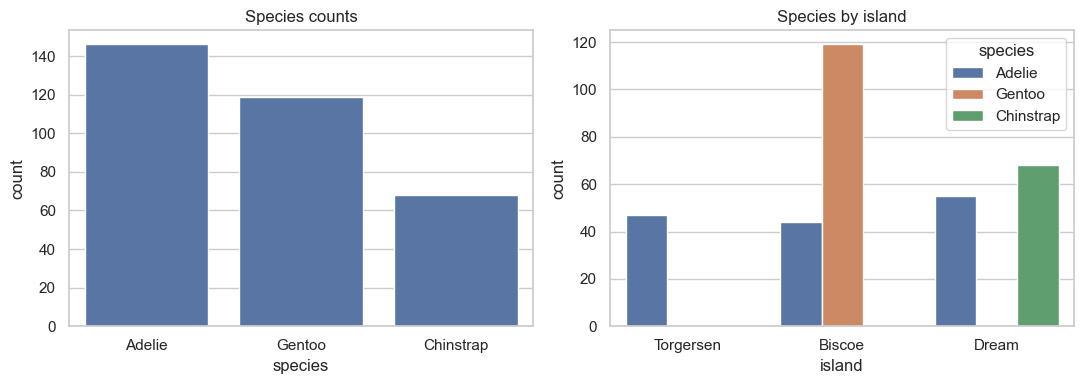

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=penguins_clean, x="species", ax=axes[0])
axes[0].set_title("Species counts")
axes[0].set_xlabel("species")
axes[0].set_ylabel("count")

sns.countplot(data=penguins_clean, x="island", hue="species", ax=axes[1])
axes[1].set_title("Species by island")
axes[1].set_xlabel("island")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

주요 신체 측정값의 종별 분포를 상자그림으로 비교한다. 상자그림을 보면 종마다 값의 중심과 퍼짐이 어떻게 다른지 한눈에 볼 수 있다.

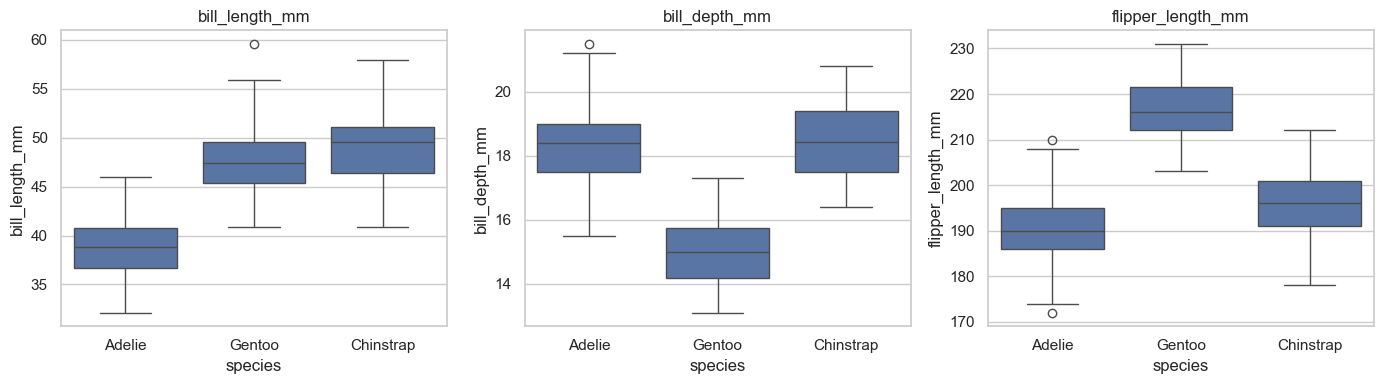

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
for feature, ax in zip(numeric_features, axes):
    sns.boxplot(data=penguins_clean, x="species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("species")

plt.tight_layout()
plt.show()

부리 길이와 부리 깊이를 이용해 종별 산점도를 그린다. 두 특성의 조합만으로도 종이 어느 정도 구분되는지 확인할 수 있어, 분류 문제의 가능성을 직관적으로 보여준다.

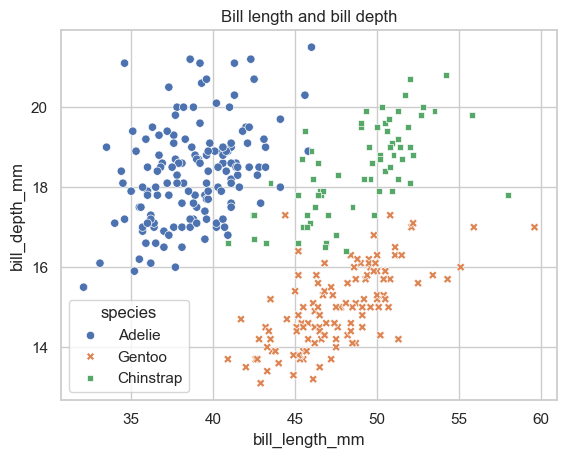

In [11]:
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
)
plt.title("Bill length and bill depth")
plt.show()

날개 길이와 몸무게의 관계를 산점도로 확인한다. 회귀 문제에서 몸무게를 예측할 때 lipper_length_mm가 유용한 입력 특성이 될 수 있는지 살펴보는 단계이다.

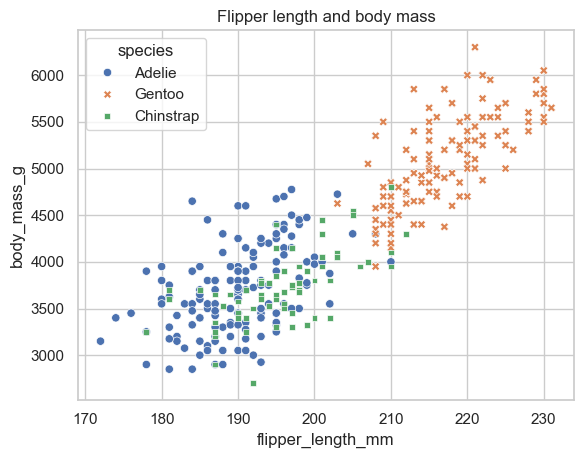

In [12]:
sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    style="species",
)
plt.title("Flipper length and body mass")
plt.show()

수치형 특성들 사이의 상관계수를 계산하고 히트맵으로 시각화한다. 상관계수는 두 변수가 함께 증가하거나 감소하는 경향을 요약하며, 회귀 문제에서 유용한 특성을 고르는 데 도움을 준다.

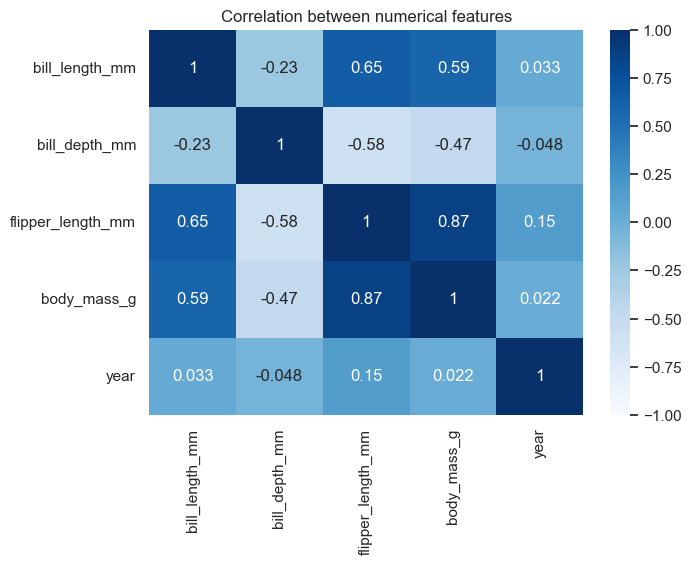

In [13]:
corr = penguins_clean.select_dtypes(include="number").corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

EDA 결과에서 다음을 확인할 수 있다.
 
 - 종마다 부리 길이와 부리 깊이의 조합이 다르게 나타난다.
 - Gentoo 펭귄은 대체로 날개가 길고 몸무게도 무겁다.
 - `flipper_length_mm`와 `body_mass_g` 사이에는 비교적 강한 양의 상관관계가 있다.
 
 이제 이 관찰을 바탕으로 두 가지 머신러닝 문제를 구성한다.

## 머신러닝 모델 훈련

파머 펭귄 데이터셋으로 두 가지 지도 학습 문제를 다룬다. 하나는 펭귄의 신체 측정값과 서식 섬, 성별 정보를 이용해 **펭귄 종을 예측하는 분류 문제**이고, 다른 하나는 같은 정보를 이용해 **몸무게를 예측하는 회귀 문제**이다. 모델을 훈련하기 전에 다음 사항을 준비한다.

- **입력 특성과 타깃 정하기**: 분류에서는 `species`를 타깃으로 두고, 회귀에서는 `body_mass_g`를 타깃으로 둔다. 타깃으로 사용할 열은 입력 특성에서 제외하여 모델이 정답을 그대로 보지 않도록 한다.

- **범주형 특성 처리하기**: `island`, `sex`처럼 문자열로 된 범주형 특성은 사이킷런 모델이 바로 사용할 수 없으므로 원-핫 인코딩 등으로 수치형 특성으로 변환한다.

- **결측치와 데이터 분할 처리하기**: 결측치가 있는 행은 제거하거나 적절히 처리한 뒤, 훈련 세트와 테스트 세트로 나눈다. 분류 문제에서는 종의 비율이 크게 달라지지 않도록 층화 분할을 사용할 수 있고, 회귀 문제에서는 테스트 세트를 따로 보관해 처음 보는 데이터에 대한 예측 성능을 확인한다.

이제 준비된 데이터를 사용하여 파머 펭귄 종 분류 모델과 몸무게 회귀 모델을 차례로 훈련한다.


### 분류: 펭귄 종 예측
 
 첫 번째 문제는 **분류**이다. 펭귄의 신체 측정값이 주어졌을 때 종을 예측한다.
 
 - 입력 특성: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
 - 타깃: `species`
 - 모델: 로지스틱 회귀
 
 로지스틱 회귀는 이름에 회귀가 들어가지만, 분류 문제에 자주 사용되는 기본 모델이다. 여러 클래스 중 하나를 예측하는 다중 분류에도 사용할 수 있다.

분류 문제에 사용할 입력 특성과 타깃을 정하고, 데이터를 훈련 세트와 테스트 세트로 나눈다. stratify=y_cls는 세 종의 비율이 훈련 세트와 테스트 세트에 비슷하게 유지되도록 해준다.

In [14]:
numeric_classification_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
categorical_classification_features = ["island", "sex"]
classification_features = numeric_classification_features + categorical_classification_features

X_cls = penguins_clean[classification_features]
y_cls = penguins_clean["species"]

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls,
)


표준화와 로지스틱 회귀를 하나의 파이프라인으로 묶어 훈련한다. 표준화는 특성들의 단위와 범위 차이를 줄여 주며, 파이프라인을 사용하면 전처리와 모델 훈련을 하나의 절차로 관리할 수 있다.

In [15]:
cls_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_classification_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_classification_features),
    ]
)

cls_model = Pipeline([
    ("preprocessor", cls_preprocessor),
    ("logistic_regression", LogisticRegression(max_iter=1000)),
])

cls_model.fit(X_cls_train, y_cls_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

테스트 세트에 대한 예측값을 만들고 정확도를 계산한다. 테스트 세트는 모델 훈련에 사용하지 않은 데이터이므로, 모델이 새로운 데이터에 어느 정도 잘 작동하는지 확인하는 데 사용한다.

In [16]:
y_cls_pred = cls_model.predict(X_cls_test)

accuracy = accuracy_score(y_cls_test, y_cls_pred)
accuracy

0.9850746268656716

정밀도, 재현율, F1 점수 등 클래스별 분류 평가 지표를 출력한다. 정확도 하나만으로는 어떤 종에서 모델이 강하거나 약한지 알기 어렵기 때문에 더 자세한 평가가 필요하다.

In [17]:
print(classification_report(y_cls_test, y_cls_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



혼동 행렬을 계산하고 그림으로 표시한다. 혼동 행렬은 실제 종과 예측 종을 함께 보여주므로, 어떤 종끼리 혼동이 발생했는지 구체적으로 확인할 수 있다.

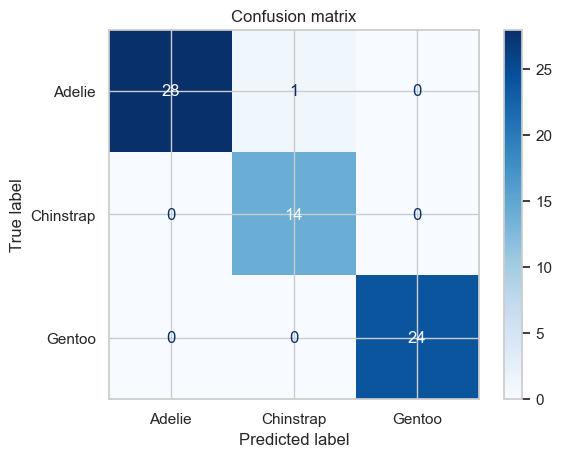

In [18]:
labels = cls_model.named_steps["logistic_regression"].classes_
cm = confusion_matrix(y_cls_test, y_cls_pred, labels=labels)

ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

정확도는 테스트 세트에서 맞힌 비율을 뜻한다. 혼동 행렬은 어떤 종을 어떤 종으로 잘못 예측했는지 보여준다. 정확도 하나만 보는 것보다 혼동 행렬을 함께 보면 모델의 실수 유형을 더 구체적으로 이해할 수 있다.

### 회귀: 펭귄 몸무게 예측
 
 두 번째 문제는 **회귀**이다. 이번에는 펭귄의 신체 측정값을 이용하여 몸무게를 예측한다.
 
 - 입력 특성: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`
 - 타깃: `body_mass_g`
 - 모델: 선형 회귀
 
 분류가 범주를 예측하는 문제라면, 회귀는 연속적인 수치를 예측하는 문제이다.

회귀 문제에 사용할 입력 특성과 타깃을 정하고, 훈련 세트와 테스트 세트로 나눈다. 여기서는 몸무게를 예측해야 하므로 ody_mass_g를 타깃으로 두고, 다른 신체 측정값을 입력으로 사용한다.

In [19]:
numeric_regression_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
]
categorical_regression_features = ["species", "island", "sex"]
regression_features = numeric_regression_features + categorical_regression_features

X_reg = penguins_clean[regression_features]
y_reg = penguins_clean["body_mass_g"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
)


표준화와 선형 회귀를 파이프라인으로 묶어 훈련한다. 선형 회귀는 입력 특성들의 선형 조합으로 몸무게를 예측하는 기본적인 회귀 모델이다.

In [20]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_regression_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_regression_features),
    ]
)

reg_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("linear_regression", LinearRegression()),
])

reg_model.fit(X_reg_train, y_reg_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

테스트 세트의 몸무게를 예측하고 MAE, RMSE, R2 점수를 계산한다. 여러 평가 지표를 함께 보면 오차의 평균적인 크기와 모델의 설명력을 동시에 판단할 수 있다.

In [21]:
y_reg_pred = reg_model.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)

,metric,value
0,MAE,204.223929
1,RMSE,277.888216
2,R2,0.870838


실제 몸무게와 예측 몸무게를 하나의 데이터프레임으로 정리한다. 몇 개의 예측 결과를 직접 비교하면 평가 지표만 볼 때보다 모델의 예측 수준을 더 구체적으로 이해할 수 있다.

In [22]:
results = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": y_reg_pred,
})

results.head(10)

,actual,predicted
30,3250.0,3246.091553
320,3675.0,3565.708737
79,4000.0,4038.806690
202,4850.0,4697.142644
63,4050.0,3961.087540
307,4300.0,4301.254615
292,3300.0,4101.360719
187,5400.0,5416.768980
219,5800.0,5565.535485
204,4400.0,4678.946714


실제값과 예측값을 산점도로 비교한다. 빨간 점선은 실제값과 예측값이 완전히 같은 경우를 나타내며, 점들이 이 선에 가까울수록 예측이 잘 된 것이다.

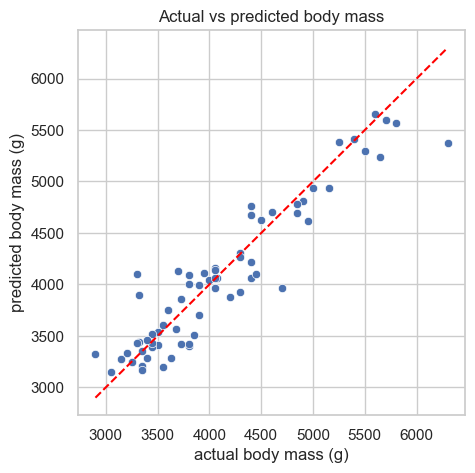

In [23]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=results, x="actual", y="predicted")

min_value = min(results["actual"].min(), results["predicted"].min())
max_value = max(results["actual"].max(), results["predicted"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")

plt.title("Actual vs predicted body mass")
plt.xlabel("actual body mass (g)")
plt.ylabel("predicted body mass (g)")
plt.show()

MAE는 예측값이 실제값에서 평균적으로 얼마나 벗어났는지를 그램 단위로 보여준다. RMSE는 큰 오차에 더 민감한 지표이다. R2 점수는 입력 특성이 타깃의 변동을 어느 정도 설명하는지 나타내며, 1에 가까울수록 좋다.
 
 회귀 결과를 산점도로 확인하면 예측값이 실제값과 얼마나 비슷한지 직관적으로 볼 수 있다. 점들이 빨간 점선에 가까울수록 예측이 잘 된 것이다.

## 정리

파머 펭귄 데이터셋은 작고 단순하지만 머신러닝 프로젝트의 핵심 흐름을 보여주기에 충분하다.

- EDA를 통해 종별 신체 특징의 차이를 확인했다.
- 분류 문제에서는 신체 측정값으로 펭귄 종을 예측했다.
- 회귀 문제에서는 신체 측정값으로 몸무게를 예측했다.
- 훈련 세트와 테스트 세트를 분리하여 모델이 새로운 데이터에서도 작동하는지 평가했다.

이 장에서 사용한 전처리는 결측치 제거와 표준화 정도로 제한했다. 이후 장에서는 더 복잡한 데이터셋을 이용하여 범주형 변수 인코딩, 결측치 대체, 특성 공학, 교차 검증, 모델 선택 등을 차례대로 다룰 수 있다.

## 연습문제
 
 **문제 1**
 
 분류 문제에서 `body_mass_g`를 제외하고 모델을 훈련해 보라. 정확도와 혼동 행렬이 어떻게 달라지는가?
 
 **문제 2**
 
 회귀 문제에서 `sex`를 입력 특성에 추가하면 몸무게 예측 성능이 좋아지는지 확인해 보라. 범주형 특성을 사용하려면 어떤 처리가 필요한가?
 
 **문제 3**
 
 분류 문제에서 `DecisionTreeClassifier` 또는 `RandomForestClassifier`를 사용해 보고 로지스틱 회귀와 성능을 비교해 보라.
 
 **문제 4**
 
 회귀 문제에서 `LinearRegression` 대신 `RandomForestRegressor`를 사용해 보라. MAE, RMSE, R2 점수를 비교하고 어떤 모델이 더 나은지 설명해 보라.